# Simulating DCR-Induced Ellipticity from Blackbody SEDs

**Differential Chromatic Refraction (DCR)** causes the atmosphere to deflect light by an angle that depends on wavelength — shorter (bluer) wavelengths are refracted more. For a broadband source, this stretches the PSF along the altitude direction, producing a measurable **ellipticity signature**.

The key dependencies are:
- **Source SED** — bluer (hotter) sources show stronger DCR because they have more flux at short wavelengths where refraction is greatest
- **Zenith angle ζ** — DCR shifts scale as tan(ζ), so the PSF second-moment contribution scales as tan²(ζ)
- **Observing band** — bluer/broader bands are more affected

This notebook simulates blackbody SEDs of varying temperatures, computes their DCR-induced PSF ellipticity across the LSST `ugrizy` bands and a range of zenith angles, and shows how the signal varies with source g−r color.

In [1]:
# Import packages and define functions

import numpy as np
import matplotlib.pyplot as plt
import galsim

from astropy.io.votable import parse
from scipy.interpolate import interp1d

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import EarthLocation, Angle, AltAz, SkyCoord

import gala.coordinates as gc
import astropy.coordinates as coord

from scipy.optimize import curve_fit

from scipy import integrate

from utils import apply_filter, apply_DCR, BB, mean_and_std


colors = {'u' : 'purple', 'g':'blue', 'r': 'green', 'i': 'orange', 'z' : 'magenta', 'y' : 'red'}

## 1. Source and Reference SEDs

We model sources as **blackbodies** parameterized by temperature. DCR shifts are always measured *relative to a reference SED* (here a 4500 K blackbody, approximating a typical survey star used for astrometric calibration). This means we compute **differential** DCR — the shift of a given source with respect to the reference — because absolute calibration removes the mean refraction.

Each SED is convolved with the LSST filter throughputs to get the per-band flux distributions that drive the DCR calculation.

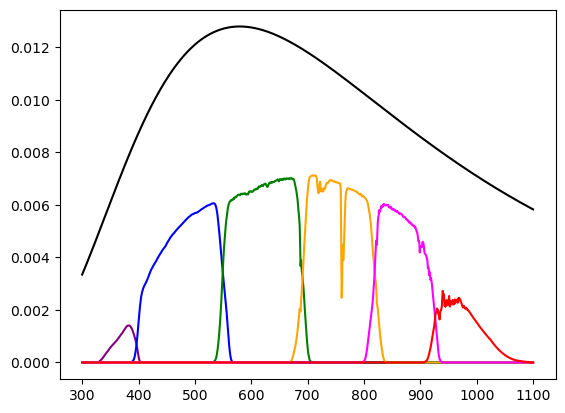

In [2]:
source_temperature = 5000     # K — source SED (will be swept over later)
reference_temperature = 4500  # K — reference SED (typical survey star for astrometric calibration)

wave = np.linspace(300, 1100, 1000)  # nm — wavelength grid spanning all LSST bands
BB_sed = BB(wave, source_temperature, scale=1e-8)
ref_sed = BB(wave, reference_temperature, scale=1e-8)

plt.plot(wave, BB_sed, 'k-')

BB_filtered = {}
ref_filtered = {}
for band in 'ugrizy':
    # Apply LSST filter throughput — selects the in-band flux that drives refraction
    filtered_sed = apply_filter(wave, BB_sed, band)
    BB_filtered[band] = filtered_sed

    filtered_ref = apply_filter(wave, ref_sed, band)
    ref_filtered[band] = filtered_ref

    plt.plot(wave, BB_filtered[band], color=colors[band], label=band)


## 2. DCR First and Second Moments

For a source with SED $S(\lambda)$ observed through filter $T(\lambda)$, the atmospheric refraction angle at each wavelength is $R(\lambda)$. The **flux-weighted moments** of $R$ determine how DCR affects the source in an image:

- **DCR1** (first moment) — the flux-weighted mean refraction of the source minus that of the reference. This is the differential astrometric centroid shift along the altitude axis.
- **DCR2** (second moment) — the flux-weighted variance of refraction: $\langle R^2 \rangle - \langle R \rangle^2$. This extra variance is added to the PSF second moment along altitude, broadening and shearing the PSF.

Both moments scale as $\tan^2(\zeta)$ with zenith angle, so we use $\tan^2(\zeta)$ as the x-axis when fitting or comparing across conditions.

Text(0, 0.5, 'Second moment shift (arcsec$^2$)')

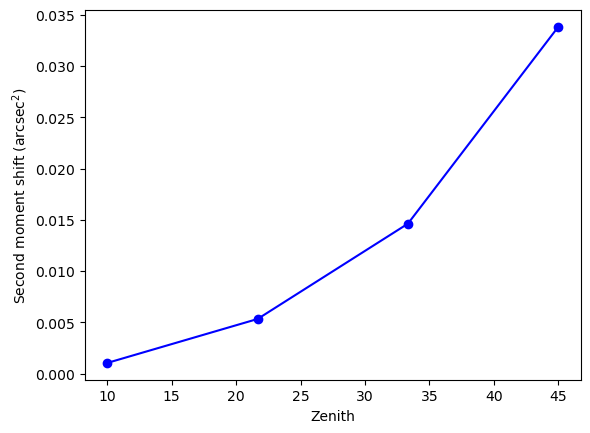

In [3]:
zeniths = np.linspace(10, 45, 4)  # zenith angles in degrees to sweep

DCR1 = {}  # differential mean refraction per band (arcsec)
DCR2 = {}  # variance of refraction per band (arcsec²) — added to PSF second moment

for band in 'ugrizy':
    DCR1[band] = np.array([])
    DCR2[band] = np.array([])

# Atmospheric conditions representative of the LSST site (Cerro Pachón)
pressure = 69.328      # kPa
temperature = 293.15   # K (~20°C)
H2O_pressure = 1.067   # kPa

for zenith in zeniths:
    # apply_DCR returns per-wavelength refraction angles and the flux-weighted SED at each angle
    refraction_angles, filtered_refracted_data = apply_DCR(wave, BB_filtered, zenith, pressure, temperature, H2O_pressure)
    R_mean, R_stdev = mean_and_std(refraction_angles, filtered_refracted_data)  # arcsec

    # Repeat for the reference SED; DCR1 is the differential shift source − reference
    refraction_angles, filtered_refracted_data_ref = apply_DCR(wave, ref_filtered, zenith, pressure, temperature, H2O_pressure)
    R_mean_ref, R_stdev_ref = mean_and_std(refraction_angles, filtered_refracted_data_ref)  # arcsec

    for band in 'ugrizy':
        DCR1[band] = np.append(DCR1[band], R_mean[band] - R_mean_ref[band])
        DCR2[band] = np.append(DCR2[band], (R_stdev[band])**2)  # variance = stdev²

plt.plot(zeniths, DCR2['g'], 'b-o', label='g')
plt.xlabel('Zenith')
plt.ylabel('Second moment shift (arcsec$^2$)')


## 3. Converting PSF Second Moments to Ellipticity

A PSF described by second moments $(I_{xx}, I_{yy}, I_{xy})$ has **distortion-convention ellipticity** components:

$$e_1 = \frac{I_{xx} - I_{yy}}{I_{xx} + I_{yy} + 2\sqrt{I_{xx} I_{yy} - I_{xy}^2}}, \qquad e_2 = \frac{2 I_{xy}}{I_{xx} + I_{yy} + 2\sqrt{I_{xx} I_{yy} - I_{xy}^2}}$$

We start from a **circular PSF** with $I_{xx} = I_{yy}$ (corresponding to a 6-pixel FWHM at 0.2″/pixel) and $I_{xy} = 0$. DCR stretches the PSF along the altitude axis (identified here with $y$), so DCR2 is added only to $I_{yy}$. This produces:
- $e_1 < 0$ — source is elongated along $y$ (altitude direction)
- $e_2 = 0$ — no 45° cross-term because DCR is purely axis-aligned

0.24000000000000005
1.1512601791080939


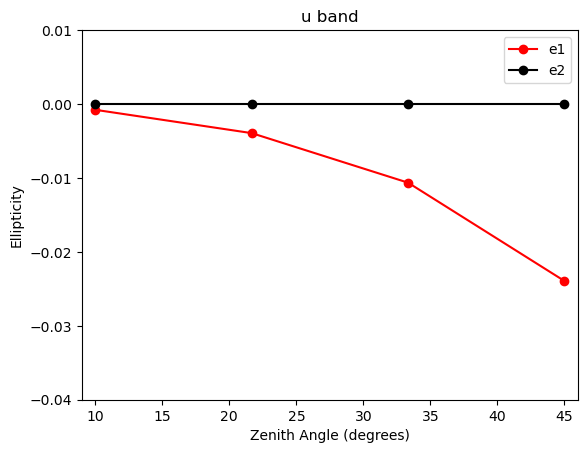

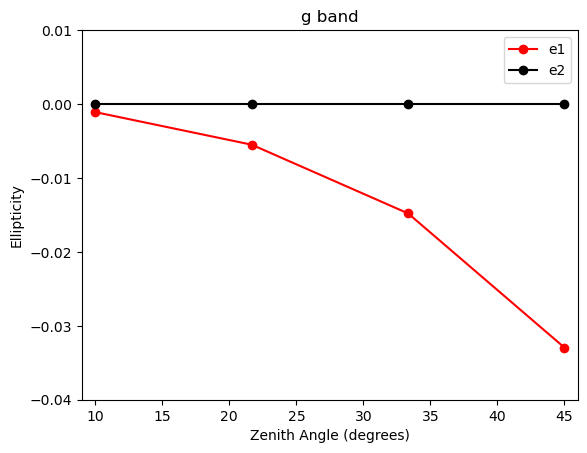

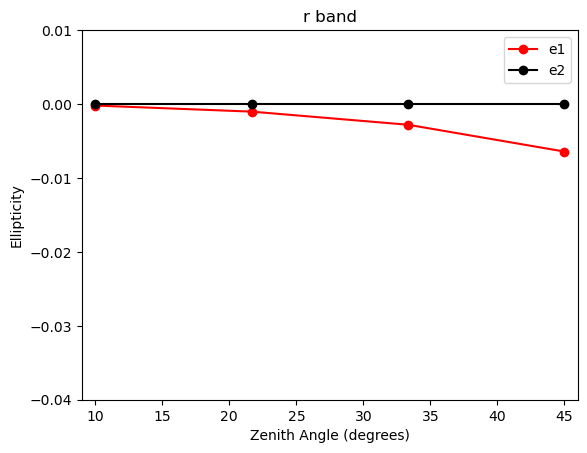

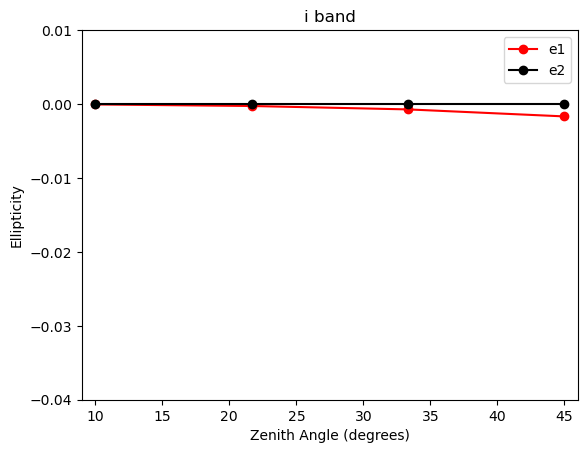

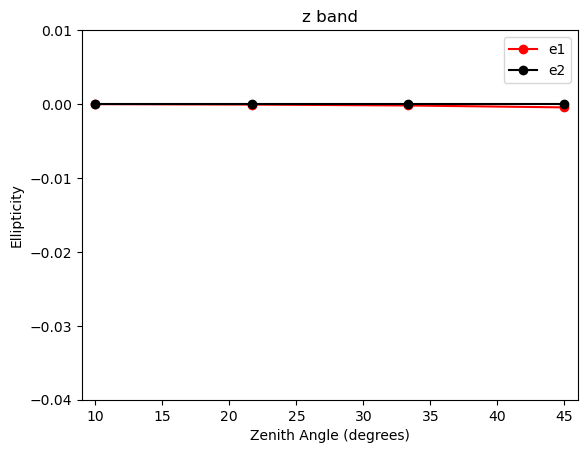

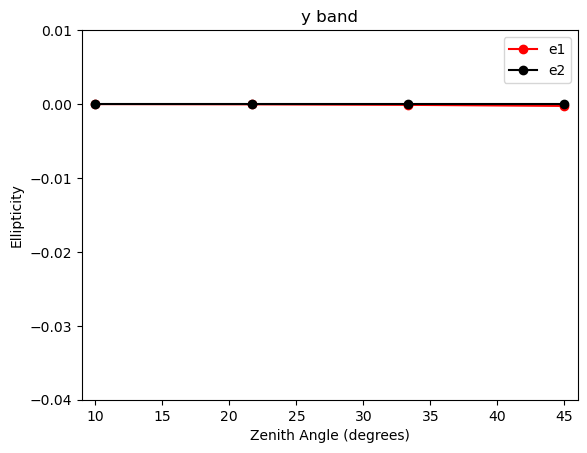

In [ ]:
# Baseline PSF second moments — circular PSF, 6 pixels × (0.2"/pixel)² plate scale
shape_xx = 6 * (0.2**2)  # arcsec² — along x (cross-altitude)
shape_yy = 6 * (0.2**2)  # arcsec² — along y (altitude); DCR2 will be added here
shape_xy = 0.0 * (0.2**2)  # arcsec² — zero for a circular PSF

print(shape_xx)
print(np.sqrt(shape_xx) * 2.35)  # equivalent FWHM in arcsec

for band in 'ugrizy':
    Ixx = np.ones(len(DCR2[band])) * shape_xx
    Iyy = np.ones(len(DCR2[band])) * shape_yy + DCR2[band]  # DCR broadens only the altitude axis
    Ixy = np.ones(len(DCR2[band])) * shape_xy

    # Distortion-convention ellipticity; denominator is the trace + 2×determinant^(1/2)
    e1 = (Ixx - Iyy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))
    e2 = (2 * Ixy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))

    # plt.plot(zeniths, e1, 'r-o', label='e1')
    # plt.plot(zeniths, e2, 'k-o', label='e2')
    # plt.xlabel('Zenith Angle (degrees)')
    # plt.ylabel(f'Ellipticity')
    # plt.title(f'{band} band')
    # plt.ylim(-0.04, 0.01)
    # plt.xlim(9, 46)
    # plt.legend()
    # plt.show()
    # plt.close()


## 4. Reusable `BB_dcr()` Function

The steps above are wrapped into a single function so we can efficiently sweep over many source temperatures. Key parameters:

| Argument | Role |
|---|---|
| `source_temperature` | Temperature of the blackbody SED being simulated |
| `reference_temperature` | Reference SED for differential DCR (fixed at 4500 K) |
| `zeniths` | Array of zenith angles to evaluate |
| `shape_xx/yy/xy` | Baseline PSF second moments before DCR |
| `return_mags` | If `True`, also returns per-band magnitudes (needed to compute g−r color) |

Returns `DCR1`, `DCR2`, `e1`, `e2` per band as arrays over the input zenith grid.

In [5]:
def BB_dcr(source_temperature, reference_temperature, zeniths, shape_xx, shape_yy, shape_xy, plot=False, noise=None, return_mags=False):

    wave = np.linspace(300, 1100, 1000)  # nm
    BB_sed = BB(wave, source_temperature, scale=1e-8)
    ref_sed = BB(wave, reference_temperature, scale=1e-8)

    BB_filtered = {}
    ref_filtered = {}
    if return_mags:
        mags = {}

    for band in 'ugrizy':
        filtered_sed = apply_filter(wave, BB_sed, band)
        BB_filtered[band] = filtered_sed

        filtered_ref = apply_filter(wave, ref_sed, band)
        ref_filtered[band] = filtered_ref

        if return_mags:
            # Instrumental magnitude — proportional to log of in-band flux integral
            mags[band] = -2.5 * np.log10(np.trapezoid(filtered_sed, wave))

    DCR1 = {}  # differential first moment (arcsec)
    DCR2 = {}  # second moment / variance (arcsec²)

    for band in 'ugrizy':
        DCR1[band] = np.array([])
        DCR2[band] = np.array([])

    pressure = 69.328      # kPa — Cerro Pachón site pressure
    temperature = 293.15   # K
    H2O_pressure = 1.067   # kPa

    for zenith in zeniths:
        refraction_angles, filtered_refracted_data = apply_DCR(wave, BB_filtered, zenith, pressure, temperature, H2O_pressure)
        R_mean, R_stdev = mean_and_std(refraction_angles, filtered_refracted_data)  # arcsec

        refraction_angles, filtered_refracted_data_ref = apply_DCR(wave, ref_filtered, zenith, pressure, temperature, H2O_pressure)
        R_mean_ref, R_stdev_ref = mean_and_std(refraction_angles, filtered_refracted_data_ref)  # arcsec

        for band in 'ugrizy':
            DCR1[band] = np.append(DCR1[band], R_mean[band] - R_mean_ref[band])
            DCR2[band] = np.append(DCR2[band], (R_stdev[band])**2)

    e1 = {}
    e2 = {}

    if plot:
        fig, ax = plt.subplots(3, 2, figsize=(12, 10), sharey=True)

    for i, band in enumerate('ugrizy'):
        Ixx = np.ones(len(DCR2[band])) * shape_xx
        Iyy = np.ones(len(DCR2[band])) * shape_yy + DCR2[band]  # add DCR2 along altitude axis
        Ixy = np.ones(len(DCR2[band])) * shape_xy

        e1[band] = (Ixx - Iyy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))
        e2[band] = (2 * Ixy) / (Ixx + Iyy + 2 * np.sqrt(Ixx * Iyy - Ixy**2))

        if plot:
            ax[i // 2, i % 2].plot(zeniths, e1[band], 'r-o', label=f'e1 {band}')
            ax[i // 2, i % 2].plot(zeniths, e2[band], 'k-o', label=f'e2 {band}')
            ax[i // 2, i % 2].legend()

    if return_mags:
        return DCR1, DCR2, e1, e2, mags
    else:
        return DCR1, DCR2, e1, e2

# zeniths = np.linspace(10, 45, 10)
# scrap = BB_dcr(7000, 4500, zeniths, shape_xx, shape_yy, shape_xy, plot=True)


## 5. Residual Ellipticity vs. Source Color

We sweep over 30 blackbody temperatures (2500–9000 K) and for each compute:
- **g−r color** — a photometric proxy for SED slope / effective temperature (bluer sources have lower g−r)
- **Residual e1** — the DCR-induced e1 of the source minus e1 of a fiducial 5000 K source

Plotting residual e1 vs. $\tan^2(\zeta)$ and grouping by g−r reveals the **color-dependent DCR ellipticity signal** that would appear in a shape catalog after subtracting a mean PSF model. The expected scaling is linear in $\tan^2(\zeta)$, with slope set by the source's color relative to the reference.

Sources are binned by g−r into three ranges roughly corresponding to:
- `[−0.3, 0.3]` — hot/blue stars and quasars
- `[0.3, 1.0]` — solar-type stars, most galaxies  
- `[1.0, 1.5]` — cool/red stars

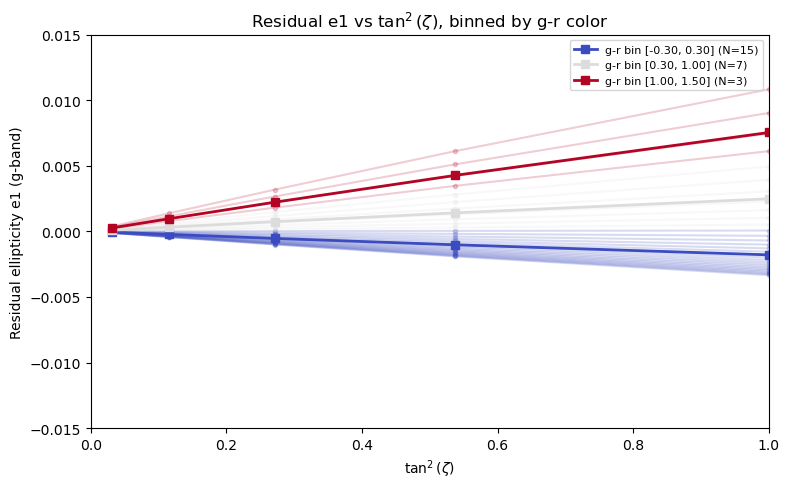

In [6]:
source_temperatures = np.linspace(2500, 9000, 30)
source_temperatures = np.flip(source_temperatures)  # hot (blue) → cool (red)
zeniths = np.linspace(10, 45, 5)
tan2z = np.tan(np.deg2rad(zeniths))**2  # x-axis: DCR scales as tan²(ζ)

# Baseline: fiducial 5000 K source used as reference point for residuals
DCR1_base, DCR2_base, e1_base, e2_base = BB_dcr(5000, 4500, zeniths, shape_xx, shape_yy, shape_xy)

gr_colors = []
resid_e1_list = []
resid_e1s = {}

for source_temperature in source_temperatures:
    DCR1, DCR2, e1, e2, mags = BB_dcr(source_temperature, 4500, zeniths, shape_xx, shape_yy, shape_xy, return_mags=True)
    gr = mags['g'] - mags['r']  # g−r color as SED proxy
    resid = e1['g'] - e1_base['g']  # residual vs. 5000 K baseline
    resid_e1s[gr] = resid
    gr_colors.append(gr)
    resid_e1_list.append(resid)

gr_colors = np.array(gr_colors)
resid_e1_arr = np.array(resid_e1_list)  # shape: (n_temps, n_zeniths)

# Bin edges in g−r color (roughly: blue / solar / red)
bin_edges = np.array([-0.3, 0.3, 1.0, 1.5])
n_bins = len(bin_edges) - 1
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

cmap = plt.cm.coolwarm
fig, ax = plt.subplots(figsize=(8, 5))

# Individual SED tracks (faint)
for i, (gr, resid) in enumerate(zip(gr_colors, resid_e1_arr)):
    bin_idx = np.clip(np.digitize(gr, bin_edges) - 1, 0, n_bins - 1)
    color = cmap(bin_idx / (n_bins - 1))
    ax.plot(tan2z, resid, '-o', color=color, alpha=0.2, markersize=3)

# Binned averages (bold)
for b in range(n_bins):
    mask = (gr_colors >= bin_edges[b]) & (gr_colors < bin_edges[b + 1])
    if b == n_bins - 1:
        mask = (gr_colors >= bin_edges[b]) & (gr_colors <= bin_edges[b + 1])
    if mask.sum() == 0:
        continue
    avg_resid = resid_e1_arr[mask].mean(axis=0)
    color = cmap(b / (n_bins - 1))
    ax.plot(tan2z, avg_resid, '-s', color=color, alpha=1.0, linewidth=2, markersize=6,
            label=f'g-r bin [{bin_edges[b]:.2f}, {bin_edges[b+1]:.2f}] (N={mask.sum()})')

ax.set_xlabel(r'$\tan^2(\zeta)$')
ax.set_ylabel('Residual ellipticity e1 (g-band)')
ax.legend(fontsize=8)
ax.set_title(r'Residual e1 vs $\tan^2(\zeta)$, binned by g-r color')
ax.set_ylim(-0.015, 0.015)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


## 6. SED Counts per g−r Color Bin

A quick sanity check: how many of the 30 blackbody SEDs fall into each g−r bin? The linear temperature grid produces uneven g−r coverage (colors compress toward the red end), so this verifies the bin occupancies before interpreting the averaged residuals above.

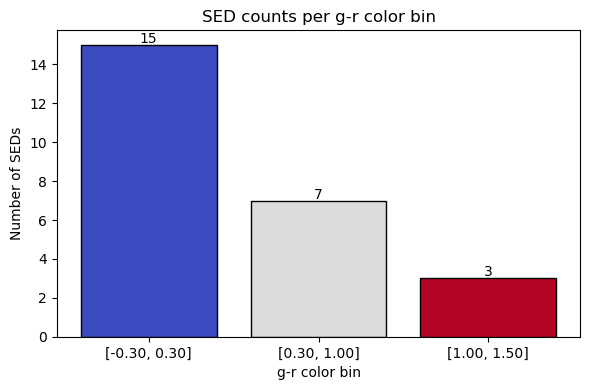

In [7]:
# Histogram of counts per g-r color bin
counts = []
labels = []
bar_colors = []
cmap = plt.cm.coolwarm

for b in range(n_bins):
    if b == n_bins - 1:
        mask = (gr_colors >= bin_edges[b]) & (gr_colors <= bin_edges[b + 1])
    else:
        mask = (gr_colors >= bin_edges[b]) & (gr_colors < bin_edges[b + 1])
    counts.append(mask.sum())
    labels.append(f'[{bin_edges[b]:.2f}, {bin_edges[b+1]:.2f}]')
    bar_colors.append(cmap(b / (n_bins - 1)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(n_bins), counts, color=bar_colors, edgecolor='k')
ax.set_xticks(range(n_bins))
ax.set_xticklabels(labels)
ax.set_xlabel('g-r color bin')
ax.set_ylabel('Number of SEDs')
ax.set_title('SED counts per g-r color bin')
for i, c in enumerate(counts):
    ax.text(i, c + 0.1, str(c), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

In [8]:
np.logspace(np.log10(3000), np.log10(9000), 30)

array([3000.        , 3115.82969353, 3236.13155969, 3361.07826861,
       3490.84915721, 3625.63048655, 3765.61570925, 3911.0057471 ,
       4062.00927946, 4218.84304277, 4381.73214167, 4550.91037203,
       4726.62055659, 4909.11489342, 5098.65531795, 5295.51387891,
       5499.9731288 , 5712.32652944, 5932.87887319, 6161.94672039,
       6399.85885378, 6646.95675033, 6903.59507143, 7170.14217188,
       7446.98062865, 7734.50778996, 8033.1363456 , 8343.29491925,
       8665.42868376, 9000.        ])